# Banking AI Assistant

## Phase 4 — Semantic Search Evaluation

This notebook evaluates semantic retrieval using:

- HuggingFace Embeddings
- all-MiniLM-L6-v2
- Cosine Similarity

Goals:

- Generate document embeddings
- Generate query embeddings
- Retrieve Top-K similar documents
- Evaluate retrieval quality

Output:

- document_embeddings.pkl
- semantic_search_test_results.csv

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import pickle
import os

from sklearn.metrics.pairwise import cosine_similarity

from langchain_huggingface import HuggingFaceEmbeddings

### Load RAG Documents

In [2]:
with open("../data/processed_data/03_rag_documents.pkl", "rb") as f:
    documents = pickle.load(f)

print("Documents Loaded:", len(documents))

Documents Loaded: 2331


#### Verify Documents

In [3]:
documents[0]

Document(metadata={'document_id': 1, 'category': 'Retail Banking', 'original_category': 'accounts', 'question': 'What are the documents required for opening a Current Account of a sole proprietorship firm'}, page_content='Category: Retail Banking\n\nQuestion: What are the documents required for opening a Current Account of a sole proprietorship firm\n\nAnswer: Following documents are required to open a Current Account of a sole proprietorship entity: Proof of existence in the name of firm Proof of address in the name of firm KYC of the proprietor Any two of the below listed documents shall be obtained for establishing proof of existence. Registration certificate/license issued by Municipal authorities such as Shop & Establishment Certificate/Trade License CST/VAT/Service Tax Certificate or Letter Of Registration for CST/VAT/Service Tax Certificate/Registration document issued by Professional Tax authorities Valid Business License or Certificate Of Registration issued by State/Central G

### Load Embedding Model

In [5]:
def load_embeddings():
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

    return embeddings

In [6]:
embeddings = load_embeddings()

print("Embedding Model Loaded Successfully")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

f:\PANTA\Projects\Banking-FAQ-RAG-System\banking_ai_assistant_venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Loaded Successfully


#### Extract Document Text

In [8]:
document_texts = [doc.page_content for doc in documents]
len(document_texts)

2331

### Generate Document Embeddings

In [ ]:
# document_embeddings = embeddings.embed_documents(document_texts)

# len(document_embeddings)

2331

In [ ]:
BATCH_SIZE = 500

document_embeddings = []

for i in range(0, len(document_texts), BATCH_SIZE):
    batch = document_texts[i:i+BATCH_SIZE]
    batch_embeddings = embeddings.embed_documents(batch)
    document_embeddings.extend(batch_embeddings)

    print(f"Processed {i+len(batch)} documents")


Processed 500 documents
Processed 1000 documents
Processed 1500 documents
Processed 2000 documents
Processed 2331 documents


2331

### Verify Embedding Shape

In [11]:
embedding_dimension = len(document_embeddings[0])

print("Embedding Dimension:", embedding_dimension)

Embedding Dimension: 384


### Save Embeddings

In [14]:
os.makedirs("../models/embeddings", exist_ok=True)

with open("../models/embeddings/document_embeddings.pkl", "wb") as f:
    pickle.dump(document_embeddings, f)

print("Document Embeddings Saved Successfully")

Document Embeddings Saved Successfully


### Build Retrieval Function

In [15]:
def retrieve_documents(query, top_k=5):
    query_embedding = (embeddings.embed_query(query))
    similarities = cosine_similarity([query_embedding], document_embeddings)[0]
    top_indices = np.argsort( similarities)[::-1][:top_k]

    results = []

    for idx in top_indices:
        results.append({
            "score": similarities[idx],
            "document": documents[idx]
        })

    return results

### Test Query #1

In [18]:
query = "How can I reset my SBI net banking password?"

results = retrieve_documents(query=query, top_k=5)

for i, result in enumerate(results):
    print("="*100)
    print("Rank:", i+1)
    print("Score:", round(result["score"],4))
    print(result["document"].metadata)
    print()

Rank: 1
Score: 0.7423
{'document_id': 1857, 'category': 'Customer Support', 'original_category': 'Customer Service', 'question': 'How do I reset my net banking password?'}

Rank: 2
Score: 0.5963
{'document_id': 535, 'category': 'Cards & Payments', 'original_category': 'cards', 'question': 'What if I forget my Prepaid NetBanking login Password'}

Rank: 3
Score: 0.588
{'document_id': 962, 'category': 'Investments & Insurance', 'original_category': 'investments', 'question': 'What if I forget my customer ID/ IPIN number'}

Rank: 4
Score: 0.5652
{'document_id': 451, 'category': 'Cards & Payments', 'original_category': 'cards', 'question': 'How to set Prepaid NetBanking Login User ID / Password for the first time'}

Rank: 5
Score: 0.5515
{'document_id': 1323, 'category': 'Digital & Security', 'original_category': 'security', 'question': 'If I forget my VBV/MSC  password, how do I retrieve the same'}



### Test Query #2

In [19]:
query = "How do I apply for a home loan?"

results = retrieve_documents(query=query, top_k=5)

for i, result in enumerate(results):
    print("="*100)
    print("Rank:", i+1)
    print(result["document"].metadata)

    print()

Rank: 1
{'document_id': 1882, 'category': 'Customer Support', 'original_category': 'Customer Service', 'question': 'How do I get a home loan pre-approval?'}

Rank: 2
{'document_id': 1144, 'category': 'Loans', 'original_category': 'loans', 'question': 'Whom do I contact in case of ay further queries regarding the loan'}

Rank: 3
{'document_id': 1208, 'category': 'Loans', 'original_category': 'loans', 'question': 'How do I apply for a Loan Against Property (LAP)'}

Rank: 4
{'document_id': 1913, 'category': 'Customer Support', 'original_category': 'Customer Service', 'question': 'What is the process to get a home loan top-up?'}

Rank: 5
{'document_id': 1230, 'category': 'Loans', 'original_category': 'loans', 'question': 'How do I apply for a Loan Against Rent Receivables (LARR)'}



### Test Query #3

In [20]:
query = "What is UPI AutoPay?"

results = retrieve_documents(query=query, top_k=5)

for i, result in enumerate(results):
    print("="*100)
    print("Rank:", i+1)
    print(result["document"].metadata)

    print()

Rank: 1
{'document_id': 1485, 'category': 'Digital & Security', 'original_category': 'Digital Banking', 'question': 'What is UPI AutoPay?'}

Rank: 2
{'document_id': 1466, 'category': 'Digital & Security', 'original_category': 'Digital Banking', 'question': 'What is UPI?'}

Rank: 3
{'document_id': 2322, 'category': 'Digital & Security', 'original_category': 'Digital Banking', 'question': 'What is a UPI mandate?'}

Rank: 4
{'document_id': 1522, 'category': 'Digital & Security', 'original_category': 'Digital Banking', 'question': 'What is UPI 123PAY?'}

Rank: 5
{'document_id': 1476, 'category': 'Digital & Security', 'original_category': 'Digital Banking', 'question': 'What is UPI ID?'}



### Batch Evaluation Queries

In [21]:
test_queries = [
    "How to open a savings account",
    "How to block my debit card",
    "How can I transfer money using UPI",
    "How to apply for personal loan",
    "What is SIP investment",
    "How to reset internet banking password",
    "What is SWIFT transfer",
    "What is RBI Ombudsman",
    "How to claim insurance",
    "What is fixed deposit"
]

### Evaluate Retrieval

In [23]:
evaluation_results = []

for query in test_queries:
    retrieved = retrieve_documents(query=query, top_k=1)
    top_result = retrieved[0]
    evaluation_results.append({
        "Query": query,
        "Similarity_Score": round(top_result["score"], 4),
        "Retrieved_Category": top_result["document"].metadata["category"],
        "Retrieved_Question": top_result["document"].metadata["question"]
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Query,Similarity_Score,Retrieved_Category,Retrieved_Question
0,How to open a savings account,0.7176,Retail Banking,What are the documents required to open a New ...
1,How to block my debit card,0.8046,Customer Support,How do I block my debit card?
2,How can I transfer money using UPI,0.6462,Digital & Security,What is UPI?
3,How to apply for personal loan,0.6492,Loans,Whom do I contact in case of ay further querie...
4,What is SIP investment,0.7377,Customer Support,What is a systematic investment plan (SIP)?
5,How to reset internet banking password,0.7955,Customer Support,How do I reset my net banking password?
6,What is SWIFT transfer,0.8167,Customer Support,What is a SWIFT transfer?
7,What is RBI Ombudsman,0.7536,Customer Support,What is a banking ombudsman?
8,How to claim insurance,0.6440,Investments & Insurance,How do I make a claim
9,What is fixed deposit,0.8042,Retail Banking,What is a Fixed Deposit?


### Similarity Score Analysis

In [24]:
evaluation_df["Similarity_Score"].describe()

count    10.000000
mean      0.736930
std       0.070012
min       0.644000
25%       0.666300
50%       0.745650
75%       0.802025
max       0.816700
Name: Similarity_Score, dtype: float64

#### Plot Similarity Scores

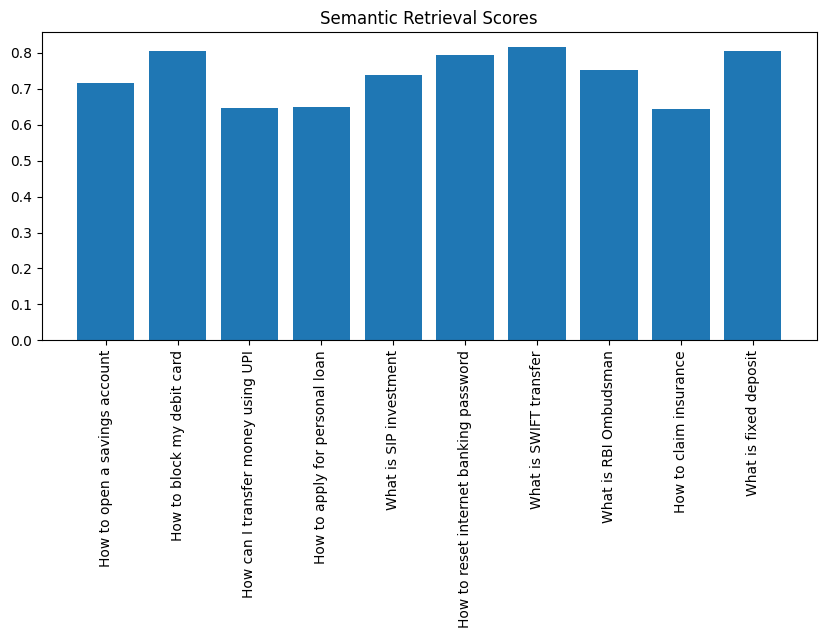

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.bar(
    evaluation_df["Query"],
    evaluation_df["Similarity_Score"]
)
plt.xticks(rotation=90)
plt.title("Semantic Retrieval Scores")

plt.show()

#### Save Evaluation Results

In [30]:
evaluation_df.to_csv("../data/output/semantic_search_test_results.csv", index=False)

#### Reload Embeddings Verification

In [31]:
with open("../models/embeddings/document_embeddings.pkl", "rb") as f:
    loaded_embeddings = pickle.load(f)

print("Embeddings Loaded:", len(loaded_embeddings))

Embeddings Loaded: 2331


#### Create Production Retrieval Function

In [32]:
def semantic_search(query, top_k=5):
    retrieved = retrieve_documents(query=query, top_k=top_k)

    return retrieved

semantic_search("How to activate credit card", top_k=3)

[{'score': 0.7377446529683069,
  'document': Document(metadata={'document_id': 340, 'category': 'Cards & Payments', 'original_category': 'cards', 'question': 'How do I activate e-commerce on my card'}, page_content='Category: Cards & Payments\n\nQuestion: How do I activate e-commerce on my card\n\nAnswer: Follow 2 simple steps: Step 1: Log on to Prepaid Card Net Banking. Step 2: Enable your e-commerce transaction facility to make purchases.')},
 {'score': 0.7221844340549295,
  'document': Document(metadata={'document_id': 363, 'category': 'Cards & Payments', 'original_category': 'cards', 'question': 'How do I activate e-commerce'}, page_content='Category: Cards & Payments\n\nQuestion: How do I activate e-commerce\n\nAnswer: Just log on to NetBanking and enable your e-commerce transaction facility.')},
 {'score': 0.7150424723409089,
  'document': Document(metadata={'document_id': 1860, 'category': 'Customer Support', 'original_category': 'Customer Service', 'question': 'How do I activat

## Key Insights

### Semantic Retrieval Successfully Implemented

Embedding Model:
- all-MiniLM-L6-v2

Embedding Size:
- 384 Dimensions

### Retrieval Process

User Query
→ Query Embedding
→ Cosine Similarity
→ Top-K Documents

### Evaluation Completed

Tested retrieval using representative banking queries.

Observed:

- High similarity scores for domain-specific questions.
- Relevant categories retrieved correctly.
- Retrieval quality suitable for FAISS vector database creation.

### Output Files

Saved:

- document_embeddings.pkl
- semantic_search_test_results.csv

These embeddings will be used in the next notebook to build the FAISS Vector Store.